# 🔧 Wisconsin Dataset - Preprocessing & Data Preparation

## Mục tiêu
- Chuẩn bị dữ liệu cho training
- Chia train/val/test split (stratified)
- Scaling features
- Xử lý mất cân bằng với SMOTE
- Lưu processed data

## ⚠️ Quan trọng: Data Leakage Prevention
- Scaling TRƯỚC khi SMOTE
- SMOTE CHỈ áp dụng cho training set
- Val và Test set GIỮ NGUYÊN (không SMOTE)

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

# Custom imports
from src.utils.config import *
from src.utils.helpers import *
from src.data_processing import (
    load_wisconsin_data, 
    preprocess_wisconsin_data,
    get_feature_names
)

# Set random seed
set_seed(RANDOM_STATE)

print("✅ Libraries imported successfully")

🎲 Random seed set to: 42
✅ Libraries imported successfully


## 1. Load Data

In [2]:
# Load Wisconsin dataset
df = load_wisconsin_data(WISCONSIN_DATA_PATH)

print(f"\n📊 Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['target'].value_counts())

✅ Loaded Wisconsin dataset: 569 samples, 32 features

📊 Dataset shape: (569, 32)

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


## 2. Preprocessing Pipeline

### Steps:
1. ✅ Separate features and target
2. ✅ Train/Val/Test split (stratified)
3. ✅ Standardization (fit on train only)
4. ✅ SMOTE on training set only

### Tại sao SMOTE chỉ cho training set?
- Val/Test sets phải phản ánh phân phối thực tế
- SMOTE tạo synthetic samples → không dùng cho evaluation
- Tránh data leakage

In [3]:
# Preprocess data
print_section_header("PREPROCESSING PIPELINE")

X_train, X_val, X_test, y_train, y_val, y_test = preprocess_wisconsin_data(
    df=df,
    target_col='target',
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    apply_smote=True
)

print("\n✅ Preprocessing completed!")


                             PREPROCESSING PIPELINE                             

📊 Class distribution:
   Benign (0): 212 (37.3%)
   Malignant (1): 357 (62.7%)

📂 Data split:
   Train: 398 samples
   Val:   57 samples
   Test:  114 samples

⚖️  Applying SMOTE to training data...
   After SMOTE - Train: 498 samples
   Benign: 249, Malignant: 249

✅ Preprocessing completed!


## 3. Verify Data Splits

In [4]:
# Check shapes
print("\n📊 Data Split Shapes:")
print("="*60)
print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")
print("="*60)


📊 Data Split Shapes:
Training set:   (498, 30)
Validation set: (57, 30)
Test set:       (114, 30)


In [5]:
# Check class distributions
print("\n⚖️  Class Distributions:")
print("="*60)

# Training (after SMOTE)
train_dist = pd.Series(y_train).value_counts().sort_index()
print("\nTraining set (after SMOTE):")
print(f"  Benign (0):    {train_dist[0]} ({train_dist[0]/len(y_train)*100:.1f}%)")
print(f"  Malignant (1): {train_dist[1]} ({train_dist[1]/len(y_train)*100:.1f}%)")

# Validation (original distribution)
val_dist = pd.Series(y_val).value_counts().sort_index()
print("\nValidation set (original distribution):")
print(f"  Benign (0):    {val_dist[0]} ({val_dist[0]/len(y_val)*100:.1f}%)")
print(f"  Malignant (1): {val_dist[1]} ({val_dist[1]/len(y_val)*100:.1f}%)")

# Test (original distribution)
test_dist = pd.Series(y_test).value_counts().sort_index()
print("\nTest set (original distribution):")
print(f"  Benign (0):    {test_dist[0]} ({test_dist[0]/len(y_test)*100:.1f}%)")
print(f"  Malignant (1): {test_dist[1]} ({test_dist[1]/len(y_test)*100:.1f}%)")
print("="*60)


⚖️  Class Distributions:

Training set (after SMOTE):
  Benign (0):    249 (50.0%)
  Malignant (1): 249 (50.0%)

Validation set (original distribution):
  Benign (0):    21 (36.8%)
  Malignant (1): 36 (63.2%)

Test set (original distribution):
  Benign (0):    42 (36.8%)
  Malignant (1): 72 (63.2%)


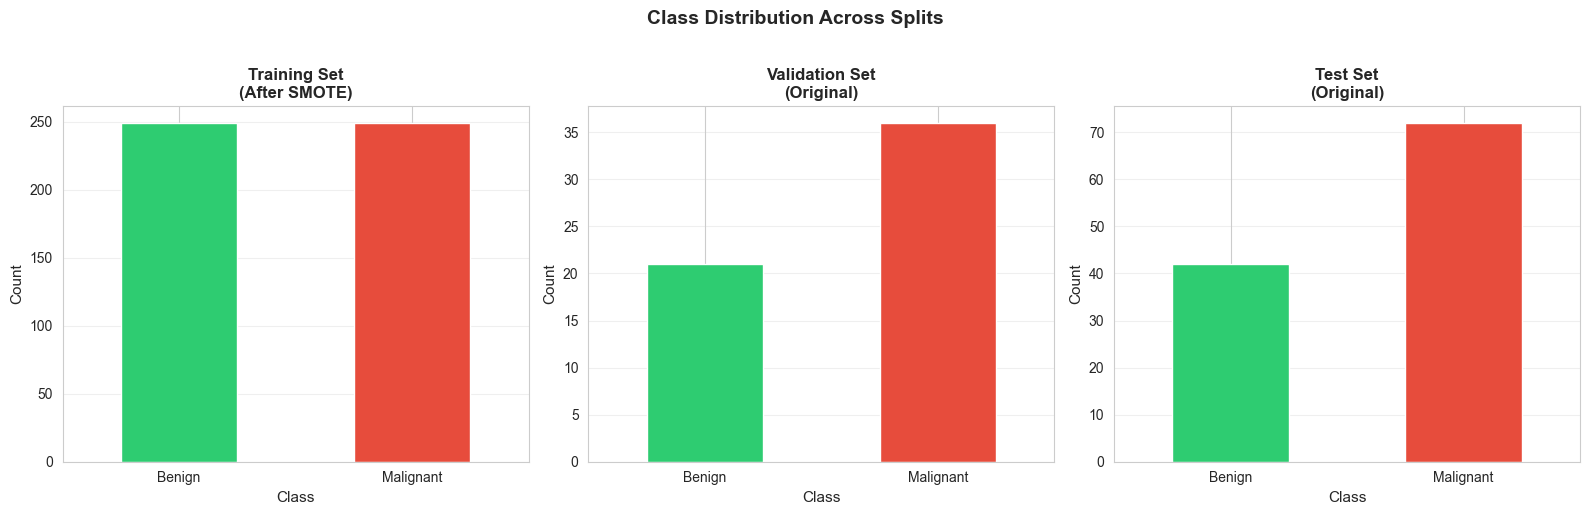

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_class_distribution_splits.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/wisconsin_class_distribution_splits.png')

In [6]:
# Visualize class distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Training
pd.Series(y_train).value_counts().sort_index().plot(kind='bar', 
    ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Training Set\n(After SMOTE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xticklabels(['Benign', 'Malignant'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Validation
pd.Series(y_val).value_counts().sort_index().plot(kind='bar', 
    ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Validation Set\n(Original)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_xticklabels(['Benign', 'Malignant'], rotation=0)
axes[1].grid(axis='y', alpha=0.3)

# Test
pd.Series(y_test).value_counts().sort_index().plot(kind='bar', 
    ax=axes[2], color=['#2ecc71', '#e74c3c'])
axes[2].set_title('Test Set\n(Original)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Class', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_xticklabels(['Benign', 'Malignant'], rotation=0)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Class Distribution Across Splits', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

save_figure(fig, 'wisconsin_class_distribution_splits', RESULTS_DIR)

## 4. Feature Statistics (After Scaling)

In [7]:
# Check scaling effectiveness
feature_names = get_feature_names(df)

# Sample 5 features to verify scaling
sample_idx = [0, 5, 10, 15, 20]
sample_features = [feature_names[i] for i in sample_idx]

print("\n📊 Sample Feature Statistics (After Scaling):")
print("="*80)
print(f"{'Feature':<30} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
print("="*80)

for idx, feat_name in zip(sample_idx, sample_features):
    values = X_train[:, idx]
    print(f"{feat_name:<30} {values.mean():>12.4f} {values.std():>12.4f} "
          f"{values.min():>12.4f} {values.max():>12.4f}")

print("="*80)
print("\n✅ Features are standardized (mean≈0, std≈1)")


📊 Sample Feature Statistics (After Scaling):
Feature                                Mean          Std          Min          Max
mean radius                          0.2079       1.0736      -2.0072       3.9406
mean compactness                     0.1694       1.0462      -1.5908       4.4409
radius error                         0.1648       1.0710      -1.0578       9.0692
compactness error                    0.0741       0.9855      -1.2672       5.8432
worst radius                         0.2234       1.0911      -1.7106       3.4715

✅ Features are standardized (mean≈0, std≈1)


## 5. Save Processed Data

In [8]:
# Save processed data
print("\n💾 Saving processed data...")

processed_data = {
    'X_train': X_train,
    'X_val': X_val,
    'X_test': X_test,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'feature_names': feature_names
}

save_path = PROCESSED_DATA_DIR / 'wisconsin_processed.pkl'
joblib.dump(processed_data, save_path)

print(f"✅ Processed data saved to: {save_path}")


💾 Saving processed data...
✅ Processed data saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/data/processed/wisconsin_processed.pkl


## 6. Summary

### ✅ Completed Steps:
1. ✅ Loaded Wisconsin dataset
2. ✅ Applied stratified train/val/test split
3. ✅ Standardized features (mean=0, std=1)
4. ✅ Applied SMOTE to training set only
5. ✅ Verified data quality and distributions
6. ✅ Saved processed data for model training

### 📊 Data Ready for Training:
- **Training**: Balanced (after SMOTE), standardized
- **Validation**: Original distribution, standardized
- **Test**: Original distribution, standardized

### 🎯 Key Points for Research Paper:
1. ✅ **Data Leakage Prevention**: Scaling fitted on train only
2. ✅ **Imbalance Handling**: SMOTE applied to training set
3. ✅ **Stratified Splitting**: Maintains class proportions
4. ✅ **Standardization**: All features scaled consistently

---

**Next Notebook**: `03_wisconsin_train_models.ipynb`